# Customer Retention and Sales Analysis using Cohort Analysis on Online Retail Data

## Objective:
The objective of this project is to analyze online retail sales data to understand customer purchasing behavior, revenue trends, product performance, and country-wise sales performance. The insights can help improve customer retention and support business growth.

## Table of Contents

1. Dataset Overview
2. Transaction Analysis
3. Product Analysis
4. Country Analysis
5. Revenue Analysis
6. Customer Analysis
7. Executive Summary
8. Business Recommendations
9. Conclusion

## Dataset Overview:
The dataset contains online retail transactions with information about customers, products, invoices, quantities, prices, countries, and transaction dates.


## Importing libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('/content/cleaned_retail_day3.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 392692 entries, 0 to 392691
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    392692 non-null  int64  
 1   StockCode    392692 non-null  object 
 2   Description  392692 non-null  object 
 3   Quantity     392692 non-null  int64  
 4   InvoiceDate  392692 non-null  object 
 5   UnitPrice    392692 non-null  float64
 6   CustomerID   392692 non-null  float64
 7   Country      392692 non-null  object 
 8   Sales        392692 non-null  float64
dtypes: float64(3), int64(2), object(4)
memory usage: 27.0+ MB


## Transaction Count

In [3]:
df['Country'].value_counts()

,count
Country,
United Kingdom,349203
Germany,9025
France,8326
EIRE,7226
Spain,2479
Netherlands,2359
Belgium,2031
Switzerland,1841
Portugal,1453


## Unique Customers

In [4]:
df['CustomerID'].nunique()

4338

## Unique Orders

In [5]:
df['InvoiceNo'].nunique()

18532

## Most Customers

In [6]:
df.groupby('Country')['CustomerID'].nunique().sort_values(ascending=False)

,CustomerID
Country,
United Kingdom,3920
Germany,94
France,87
Spain,30
Belgium,25
Switzerland,21
Portugal,19
Italy,14
Finland,12


In [7]:
df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country', 'Sales'],
      dtype='object')

In [8]:
df['Revenue'] = df['Quantity'] * df['UnitPrice']

In [9]:
df[['Quantity','UnitPrice','Revenue']].head()

,Quantity,UnitPrice,Revenue
0,6,2.55,15.30
1,6,3.39,20.34
2,8,2.75,22.00
3,6,3.39,20.34
4,6,3.39,20.34


## Exploratory Data Analysis

Objectives:
- Top 10 Countries by Transaction Count
- Top 10 Products by Quantity Sold
- Top 10 Products by Revenue
- Top 10 Countries by Revenue

## Top 10 Countries by Transaction Count

In [10]:
top_countries = ( df.groupby('Country')['InvoiceNo'].count().sort_values(ascending=False).head(10)
)
top_countries

,InvoiceNo
Country,
United Kingdom,349203
Germany,9025
France,8326
EIRE,7226
Spain,2479
Netherlands,2359
Belgium,2031
Switzerland,1841
Portugal,1453


## Chart

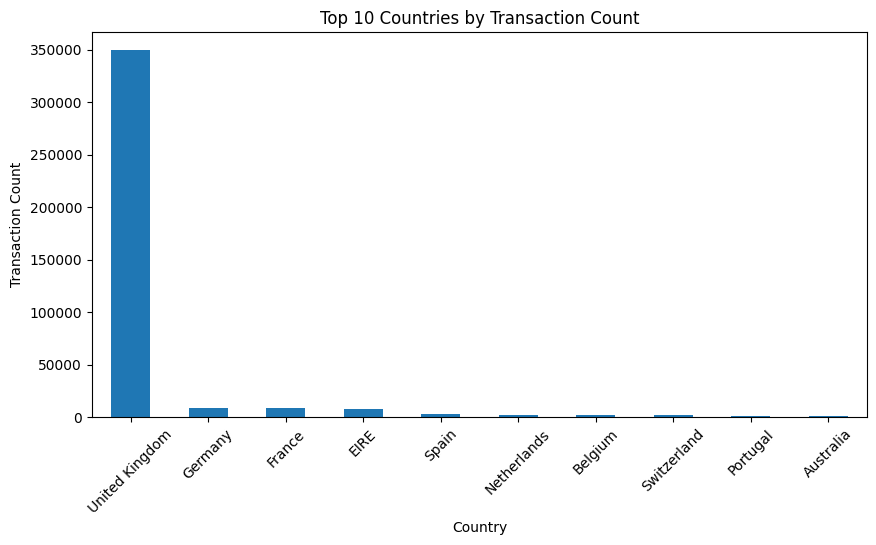

In [11]:
plt.figure(figsize=(10,5))
top_countries.plot(kind='bar')
plt.title('Top 10 Countries by Transaction Count')
plt.xlabel('Country')
plt.ylabel('Transaction Count')
plt.xticks(rotation=45)
plt.show()

### Findings
The United Kingdom dominates transaction volume, indicating a much larger customer base and order frequency than other countries. The gap between the top country and the remaining countries suggests that sales are concentrated in a few key markets.

## Top 10 Countries by Quantity sold

In [12]:
top_products_qty = (df.groupby('Description')['Quantity'].sum().sort_values(ascending=False) .head(10))
top_products_qty

,Quantity
Description,
"PAPER CRAFT , LITTLE BIRDIE",80995
MEDIUM CERAMIC TOP STORAGE JAR,77916
WORLD WAR 2 GLIDERS ASSTD DESIGNS,54319
JUMBO BAG RED RETROSPOT,46078
WHITE HANGING HEART T-LIGHT HOLDER,36706
ASSORTED COLOUR BIRD ORNAMENT,35263
PACK OF 72 RETROSPOT CAKE CASES,33670
POPCORN HOLDER,30919
RABBIT NIGHT LIGHT,27153


## Chart

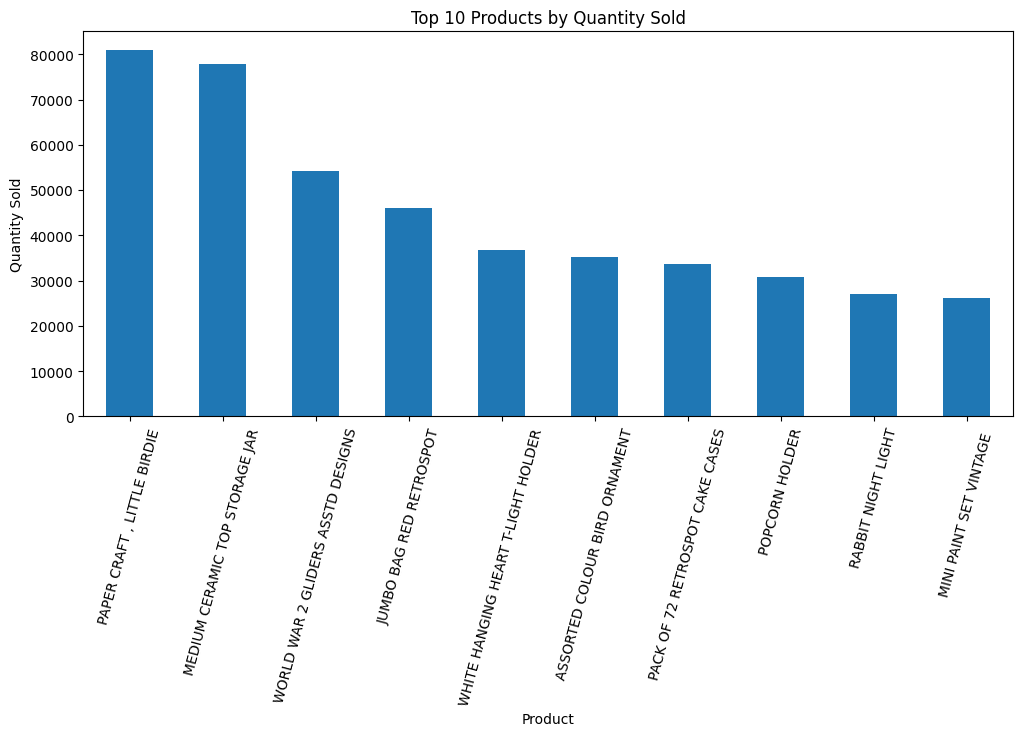

In [13]:
plt.figure(figsize=(12,5))
top_products_qty.plot(kind='bar')
plt.title('Top 10 Products by Quantity Sold')
plt.xlabel('Product')
plt.ylabel('Quantity Sold')
plt.xticks(rotation=75)
plt.show()

### Findings
A small set of products accounts for a large share of total units sold, highlighting strong customer demand for these items. These products should be prioritized for inventory planning and stock management. Monitoring their availability can help prevent lost sales opportunities.

## Top 10 Products by Revenue

In [14]:
top_products_rev = (df.groupby('Description')['Revenue'].sum().sort_values(ascending=False).head(10))
top_products_rev

,Revenue
Description,
"PAPER CRAFT , LITTLE BIRDIE",168469.60
REGENCY CAKESTAND 3 TIER,142264.75
WHITE HANGING HEART T-LIGHT HOLDER,100392.10
JUMBO BAG RED RETROSPOT,85040.54
MEDIUM CERAMIC TOP STORAGE JAR,81416.73
POSTAGE,77803.96
PARTY BUNTING,68785.23
ASSORTED COLOUR BIRD ORNAMENT,56413.03
Manual,53419.93


## Chart

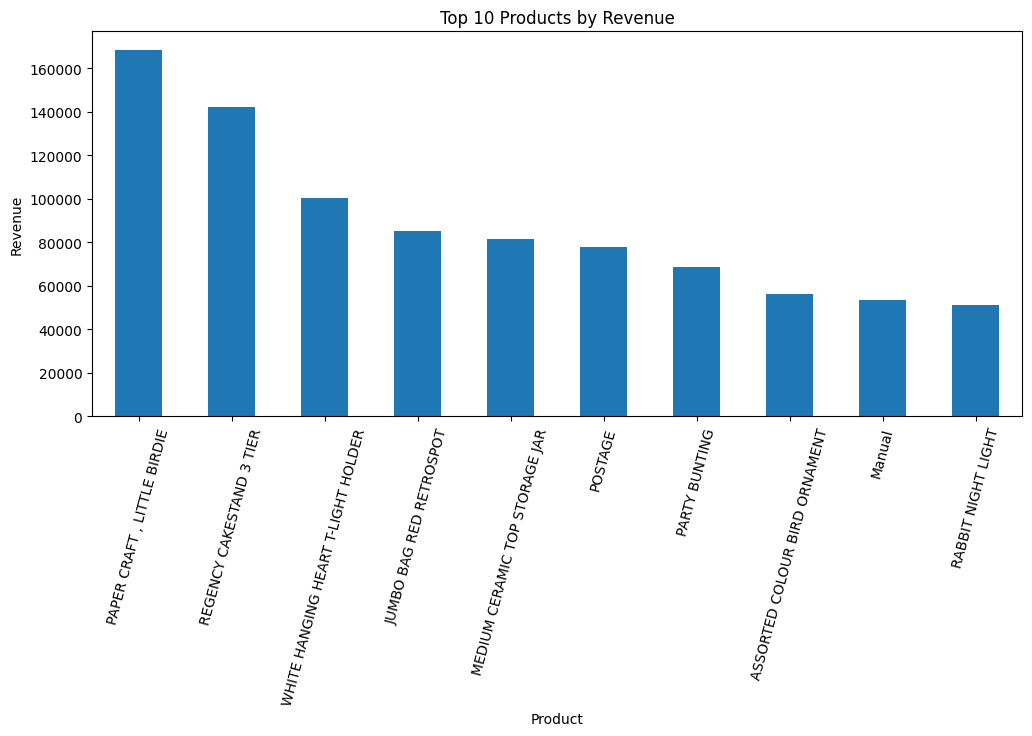

In [15]:
plt.figure(figsize=(12,5))
top_products_rev.plot(kind="bar")
plt.title("Top 10 Products by Revenue")
plt.xlabel("Product")
plt.ylabel("Revenue")
plt.xticks(rotation=75)
plt.show()

###Findings

This chart shows the products that earned the most money. PAPER CRAFT, LITTLE BIRDIE has the highest revenue, followed by REGENCY CAKESTAND 3rd. These products are important because they bring more sales to the business than other products.

## Country Analysis:

This section evaluates country-wise transactions, customer distribution, and revenue contribution to identify the strongest markets.

## Top 10 Countries by Revenue

In [16]:
top_country_rev = ( df.groupby('Country')['Revenue'].sum().sort_values(ascending=False).head(10)
)

top_country_rev

,Revenue
Country,
United Kingdom,7285024.644
Netherlands,285446.340
EIRE,265262.460
Germany,228678.400
France,208934.310
Australia,138453.810
Spain,61558.560
Switzerland,56443.950
Belgium,41196.340


## Chart

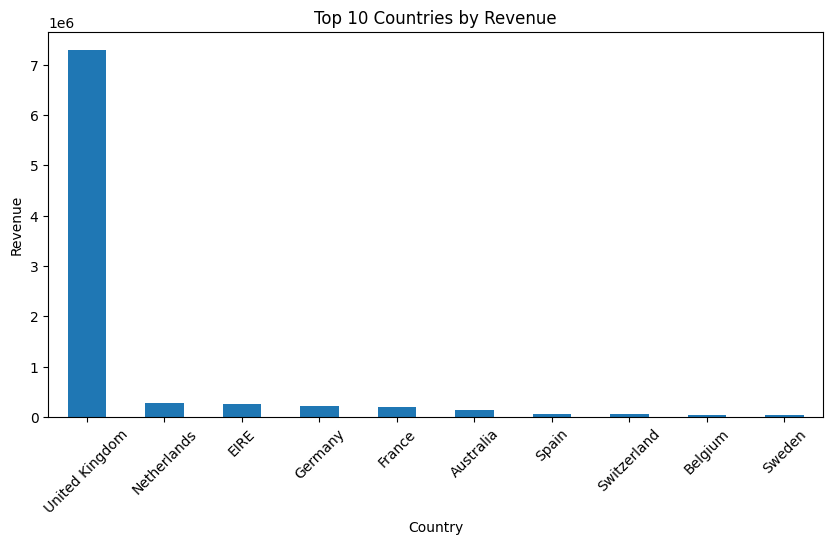

In [17]:
plt.figure(figsize=(10,5))
top_country_rev.plot(kind='bar')
plt.title('Top 10 Countries by Revenue')
plt.xlabel('Country')
plt.ylabel('Revenue')
plt.xticks(rotation=45)
plt.show()

### Findings
Revenue generation is heavily concentrated among a few countries, with the leading market contributing a substantial share of total sales. High-revenue countries represent important opportunities for customer retention and targeted marketing. Understanding purchasing behavior in these regions can support future revenue growth.

## Product Analysis:

This section identifies the most popular products based on quantity sold and the products generating the highest revenue.

## Most Popular Products

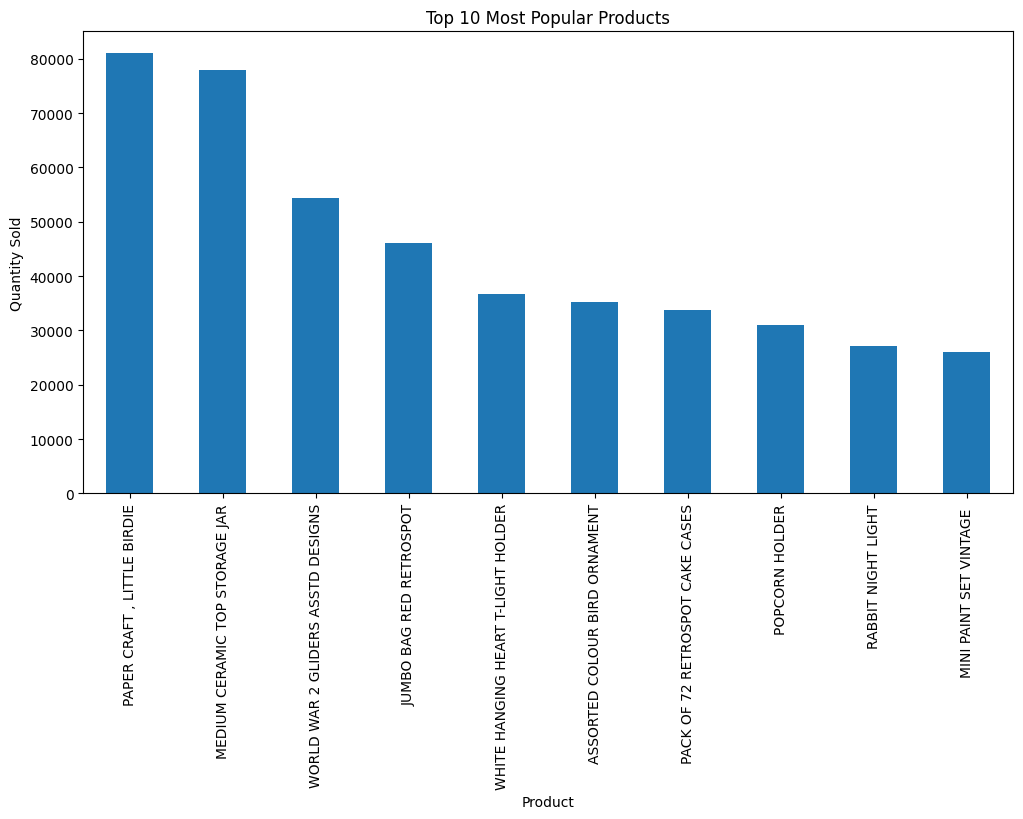

In [18]:
popular_products = df.groupby('Description')['Quantity'].sum().sort_values(ascending=False)
plt.figure(figsize=(12,6))
popular_products.head(10).plot(kind='bar')
plt.title('Top 10 Most Popular Products')
plt.xlabel('Product')
plt.ylabel('Quantity Sold')
plt.show()

### Findings
- The most popular product is PAPER CRAFT.LITTLE BIRDIE.
- These products have the highest demand among customers.
- Inventory planning should prioritize these products.

## Convert InvoiceDate to Datetime

In [19]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 392692 entries, 0 to 392691
Data columns (total 10 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    392692 non-null  int64         
 1   StockCode    392692 non-null  object        
 2   Description  392692 non-null  object        
 3   Quantity     392692 non-null  int64         
 4   InvoiceDate  392692 non-null  datetime64[ns]
 5   UnitPrice    392692 non-null  float64       
 6   CustomerID   392692 non-null  float64       
 7   Country      392692 non-null  object        
 8   Sales        392692 non-null  float64       
 9   Revenue      392692 non-null  float64       
dtypes: datetime64[ns](1), float64(4), int64(2), object(3)
memory usage: 30.0+ MB


In [21]:
df['Month'] = df['InvoiceDate'].dt.to_period('M')

## Revenue Analysis:

This section analyzes revenue generated across products, customers, countries, and time periods to identify major revenue contributors and business trends.



## Monthly Revenue Trend Chart

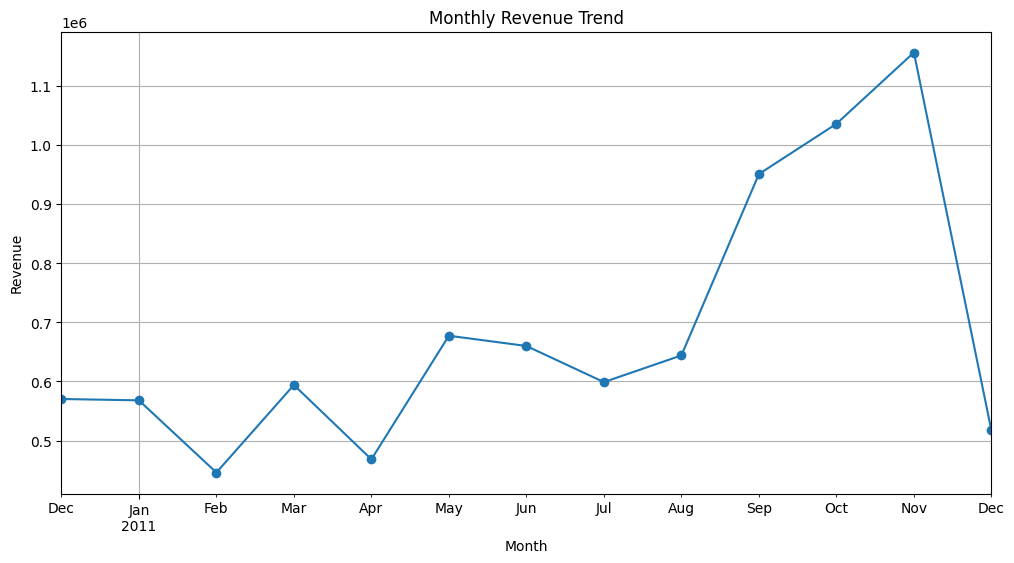

In [24]:
monthly_revenue = df.groupby('Month')['Revenue'].sum()
plt.figure(figsize=(12,6))
monthly_revenue.plot(marker='o')
plt.title('Monthly Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Revenue')
plt.grid(True)
plt.show()

### Findings
Monthly revenue shows fluctuations over time, indicating periods of stronger and weaker customer demand. Seasonal patterns or promotional campaigns may influence these changes. Tracking revenue trends helps businesses plan inventory, staffing, and marketing activities more effectively.

## Customer Analysis:

This section focuses on customer purchasing behavior and identifies high-value customers contributing the most revenue.

## Top 10 Customers by Revenue

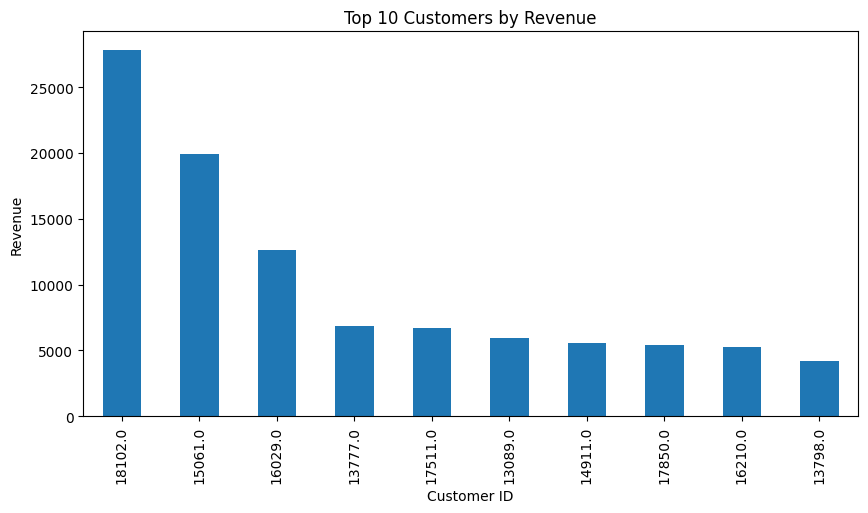

In [ ]:
customer_revenue = df.groupby('CustomerID')['Revenue'].sum().sort_values(ascending=False)
plt.figure(figsize=(10,5))
customer_revenue.head(10).plot(kind='bar')
plt.title('Top 10 Customers by Revenue')
plt.xlabel('Customer ID')
plt.ylabel('Revenue')
plt.show()

### Findings
- A small group of customers contributes a significant portion of revenue.
- Retaining these high-value customers is critical for business growth.
- Loyalty programs can help increase customer retention.

## Executive Summary

### Customer Purchasing Behavior
Customers tend to purchase a limited set of products repeatedly, with a small group of products accounting for the highest sales volumes. Additionally, a relatively small number of customers generate a large share of revenue, highlighting the importance of customer retention.

### Revenue Trends
Revenue varies across months, indicating changing customer demand over time. Monitoring these trends can help the business identify seasonal patterns and improve planning for inventory and marketing campaigns.

### Top-Performing Products
The highest-selling products contribute significantly to both sales volume and revenue. These products should remain a priority for inventory management, promotions, and product availability.

### Top-Performing Countries
The United Kingdom is the leading market in both transaction count and revenue generation. Other top-performing countries also contribute substantially and represent valuable opportunities for expansion and customer engagement.

## Final EDA Insights

1. The United Kingdom has the highest transaction count, making it the most active market.
2. The United Kingdom also generates the highest revenue, showing strong customer demand and spending.
3. A small number of products account for a large share of total sales volume.
4. High-revenue products are key drivers of overall business performance and profitability.
5. Monthly revenue trends indicate fluctuations in customer demand throughout the year.
6. A small group of customers contributes a significant percentage of total revenue.
7. Customer retention strategies focused on top customers can have a major impact on future revenue growth.
8. Country-level performance analysis can help identify markets with the greatest growth potential.


## Business Recommendations

1. Strengthen customer retention strategies for high-revenue customers through loyalty programs.
2. Increase inventory levels for the most frequently purchased products to avoid stock shortages.
3. Focus promotional campaigns on top-performing products that generate the highest revenue.
4. Expand business operations and marketing efforts in the United Kingdom, as it contributes the highest revenue and transaction volume.
5. Use customer purchase history to create personalized product recommendations.
6. Monitor monthly revenue trends to improve demand forecasting and inventory planning.
7. Encourage repeat purchases through targeted discounts and seasonal offers.
8. Analyze low-performing countries to identify opportunities for market growth.
9. Regularly track customer and product performance metrics to support business decisions.
10. Continue using data analytics to optimize sales, customer retention, and revenue growth.

## Conclusion

This EDA of the Online Retail dataset provided valuable insights into customer behavior, product performance, revenue trends, and country-wise sales distribution.

### Customer Behavior
A small group of customers generates a significant share of revenue, making customer retention important for business growth.

### Product Performance
A few products contribute most of the sales and revenue, highlighting the need for effective inventory and marketing strategies.

### Revenue Trends
Monthly revenue patterns show fluctuations in customer demand, which can help improve forecasting and planning.

### Country Performance
The United Kingdom is the top-performing market in terms of transactions and revenue, while other countries offer opportunities for future growth.

Overall, the analysis highlights the importance of customer retention, product optimization, and data-driven decision-making to improve business performance.